                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape: (460048, 14)
Test shape: (115013, 14)
[LightGBM] [Info] Number of positive: 13470, number of negative: 446578
[LightGBM] [Info] Auto-choosing row-wise multi-threading, t

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[111505    140]
 [   298   3070]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111645
           1       0.96      0.91      0.93      3368

    accuracy                           1.00    115013
   macro avg       0.98      0.96      0.97    115013
weighted avg       1.00      1.00      1.00    115013



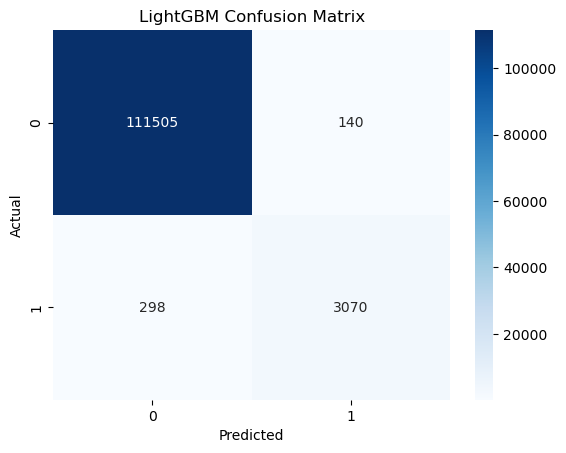

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC: 0.9615975236021795


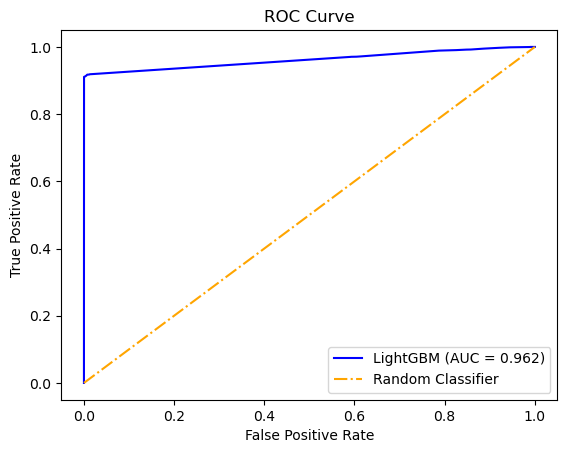

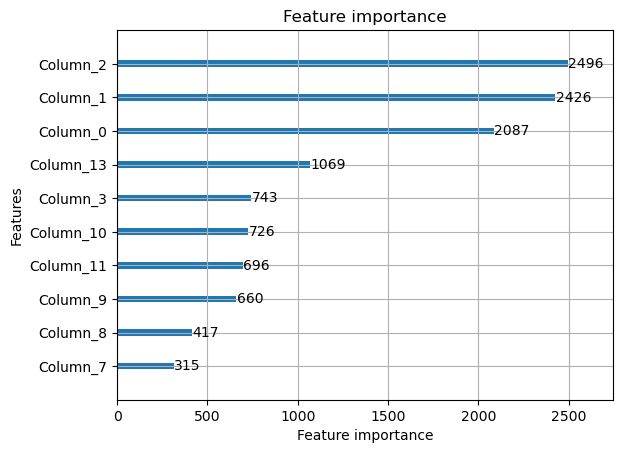

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Loading preprocessed data
df = pd.read_csv("processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

# Features and labels
x = df.drop(["BlockId","Label"], axis=1)
y = df["Label"]

# Remove weak features
selector = VarianceThreshold(threshold=0.01)
x = selector.fit_transform(x)

# Log transform
x = np.log1p(x)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# LightGBM model
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

# Train
lgbm.fit(x_train, y_train)

# Predictions
y_pred = lgbm.predict(x_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")

plt.show()

# Probability scores for ROC
y_prob = lgbm.predict_proba(x_test)[:,1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, color='blue', label=f'LightGBM (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='dashdot', color='orange', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

import lightgbm as lgb

lgb.plot_importance(lgbm, max_num_features=10)
plt.show()